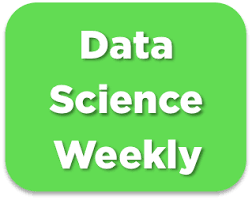

# Challenge : predict conversions 🏆🏆

This is the template that shows the different steps of the challenge. In this notebook, all the training/predictions steps are implemented for a very basic model (logistic regression with only one variable). Please use this template and feel free to change the preprocessing/training steps to get the model with the best f1-score ! May the force be with you 🧨🧨  

**For a detailed description of this project, please refer to *02-Conversion_rate_challenge.ipynb*.**

# Import libraries

In [521]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)  # to avoid deprecation warnings

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from IPython.display import display

# Read file with labels

In [522]:
df = pd.read_csv("df.csv")

# Preprocessing

## preprocessing pandas

Detect outlyers age and total_pages_visited. We apply 3 sigma rule : to 1 sigma from mean, 60% of dataset is included in area. To 2 sigma, 95% and to 3 sigma, 99%. Then we drop entries outside 3 sigma from the mean.

In [523]:
string = ['country', 'source']

for col in string:
    df[col] = df[col].str.lower()

### drop outlyers

In [524]:
upper_bound = 80
mask = df['age'] < upper_bound
mask

0         True
1         True
2         True
3         True
4         True
          ... 
284575    True
284576    True
284577    True
284578    True
284579    True
Name: age, Length: 284580, dtype: bool

In [525]:
df = df.loc[mask, :]
print("Done. Number of lines remaining : ", df.shape[0])
print(df.head())

Done. Number of lines remaining :  284578
   country  age  new_user  source  total_pages_visited  converted
0    china   22         1  direct                    2          0
1       uk   21         1     ads                    3          0
2  germany   20         0     seo                   14          1
3       us   23         1     seo                    3          0
4       us   28         1  direct                    3          0


In [526]:
df.describe(include='all')

,country,age,new_user,source,total_pages_visited,converted
count,284578,284578.000000,284578.000000,284578,284578.000000,284578.000000
unique,4,NaN,NaN,3,NaN,NaN
top,us,NaN,NaN,seo,NaN,NaN
freq,160124,NaN,NaN,139476,NaN,NaN
mean,NaN,30.563596,0.685457,NaN,4.873198,0.032251
std,NaN,8.263627,0.464334,NaN,3.341939,0.176667
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000


## preprocessing en sklearn

### Multivariate linear regression

#### Separate target variable Y from features X

In [527]:
# Separate target variable Y from features X

print("Separating labels from features...")
target = 'converted'

y = df.loc[:, target]# or df.iloc[:, -1] # or  df.loc[:, df.columns == target]
X = df.drop(target, axis=1) # or df.iloc[:, 0:-1]  # All columns are kept, except the target
# or df.loc[:, df.columns != target]
print("...Done.")

print("y : ")
print(y.head())
print()
print("X : ")
print(X.head())

Separating labels from features...
...Done.
y : 
0    0
1    0
2    1
3    0
4    0
Name: converted, dtype: int64

X : 
   country  age  new_user  source  total_pages_visited
0    china   22         1  direct                    2
1       uk   21         1     ads                    3
2  germany   20         0     seo                   14
3       us   23         1     seo                    3
4       us   28         1  direct                    3


In [528]:
# Automatically detect names of numeric/categorical columns
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Found numeric features ", numeric_features)
print("Found categorical features ", categorical_features)

Found numeric features  ['age', 'new_user', 'total_pages_visited']
Found categorical features  ['country', 'source']


#### divide dataset train set & test set 

We apply different transformations to the features, depending on their types. Numeric columns will be standardized whereas categorical columns will be one-hot-encoded. As regards missing values imputation, it can apply to every column, but different rules may be used. 

In [529]:
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
# WARNING : don't forget stratify=Y for classification problems
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



We don't use simple imputer because we don't have any missing values. num_imputer = SimpleImputer(strategy="median")

We normalize numeric colomns to scale them down.

#### pipelines

In [530]:
print("Preprocessing X_train...")
print(X_train.head())
print()

# categoric

cat_transformer = Pipeline(steps=[
    ('catEncoder', OneHotEncoder(drop='first'))
])
# numerical

num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

Preprocessing X_train...
        country  age  new_user  source  total_pages_visited
14322        uk   37         1     ads                    3
251570       uk   27         0     seo                   13
53008        us   26         0  direct                    4
121373       us   24         0     seo                    1
151639  germany   33         0     ads                    2



In [531]:
#### pipeline global
print("Encoding categorical features and standardizing numerical features...")

preprocessor = ColumnTransformer(transformers=[
    ('cat_transformer', cat_transformer, categorical_features),
    ('num_transformer', num_transformer, numeric_features)
])

# Preprocessings on train set
print("Preprocessing sur le train set...")
X_train = preprocessor.fit_transform(X_train)
print('...Terminé.')
X_train[0:5] # MUST use this syntax because X_train is a numpy array and not a pandas DataFrame anymore
print()


Encoding categorical features and standardizing numerical features...
Preprocessing sur le train set...
...Terminé.



Nous n'utilisons pas labelEncoder sur y_test car les labels sont déjà convertis sur converted

#### Test pipeline

In [532]:
# Preprocessings sur le test set
print("Preprocessing on test set...")
X_test = preprocessor.transform(X_test) # Don't fit again !! The test set is used for validating decisions
# we made based on the training set, therefore we can only apply transformations that were parametered using the training set.
# Otherwise this creates what is called a leak from the test set which will introduce a bias in all your results.
print('...Done.')
X_test[:5, :] # MUST use this syntax because X_test is a numpy array and not a pandas DataFrame anymore

Preprocessing on test set...
...Done.


array([[ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.77869487,  0.67629326, -0.86022495],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.62497205,  0.67629326, -0.56105227],
       [ 0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
        -0.79296275, -1.47864847,  3.32819262],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.41600465,  0.67629326, -0.56105227],
       [ 0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        -0.79296275,  0.67629326,  0.0372931 ]])

#### Train model

In [533]:

from sklearn.linear_model import LinearRegression

print("Train model...")
regressor = LinearRegression() # 
regressor.fit(X_train, y_train)
print("...Done.")

Train model...
...Done.


#### Performance evaluation

#### Predictions

In [534]:
# Predictions on training set
print("Predictions on training set...")
y_train_pred = regressor.predict(X_train)
print("...Done.")
print(y_train_pred)
print()

Predictions on training set...
...Done.
[-0.02434641  0.30006969  0.04369471 ... -0.07497892  0.01586988
  0.13965893]



In [535]:
# Predictions on test set
print("Predictions on test set...")
y_test_pred = regressor.predict(X_test)
print("...Done.")
print(y_test_pred)
print()

Predictions on test set...
...Done.
[-0.09214517 -0.06950603  0.3816868  ...  0.07618843 -0.00259917
  0.01493857]



In [536]:
### Cross-validated score for a Ridge model (with default value of λλ)
# Perform 3-fold cross-validation to evaluate the generalized R2 score obtained with a Ridge model
print("3-fold cross-validation...")
regressor = Ridge()
scores = cross_val_score(regressor, X_train, y_train, cv=10)
print('The cross-validated R2-score is : ', scores.mean())
print('The standard deviation is : ', scores.std())
### Grid search : tune λλ
# Perform grid search
print("Grid search...")
regressor = Ridge()
# Grid of values to be tested
params = {
    'alpha': [0.1, 0.5, 1.0, 10.0, 45.74, 45.75, 45.76, 50.0] # 0 corresponds to no regularization
}
gridsearch = GridSearchCV(regressor, param_grid = params, cv = 10) # cv : the number of folds to be used for CV
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best R2 score : ", gridsearch.best_score_)


3-fold cross-validation...
The cross-validated R2-score is :  0.30096311950860344
The standard deviation is :  0.012552867399111293
Grid search...
...Done.
Best hyperparameters :  {'alpha': 45.75}
Best R2 score :  0.30096326837086435


In [537]:
ridge1 = Ridge(alpha = 45.75)
print(ridge1)
ridge1.fit(X_train, y_train)
# Print R^2 scores
print("R2 score on training set : ", ridge1.score(X_train, y_train))
print("R2 score on test set : ", ridge1.score(X_test, y_test))

Ridge(alpha=45.75)
R2 score on training set :  0.30144612627219936
R2 score on test set :  0.3011102938281812


### Cross-validated score for a Ridge model (with default value of λλ)

In [538]:
# Perform 3-fold cross-validation to evaluate the generalized R2 score obtained with a Ridge model
print("3-fold cross-validation...")
regressor = Ridge()
scores = cross_val_score(regressor, X_train, y_train, cv=5)
print('The cross-validated R2-score is : ', scores.mean())
print('The standard deviation is : ', scores.std())

3-fold cross-validation...
The cross-validated R2-score is :  0.30117717178155756
The standard deviation is :  0.007060673530079812


### Grid search : tune λλ

In [539]:
# Perform grid search
print("Grid search...")
regressor = Ridge()
# Grid of values to be tested
params = {
    'alpha': [0.1, 0.5, 1.0, 10.0, 25.0, 29.85, 29.86, 29.87, 50.0] # 0 corresponds to no regularization
}
gridsearch = GridSearchCV(regressor, param_grid = params, cv = 5) # cv : the number of folds to be used for CV
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best R2 score : ", gridsearch.best_score_)


Grid search...
...Done.
Best hyperparameters :  {'alpha': 29.86}
Best R2 score :  0.3011772504398797


- Ridge 1 : alpha': 45.75 cv = 10 R2 score on training set :  0.30144610180887776
R2 score on test set :  0.3011099776729932
- Ridge 2 : 'alpha': 29.86 cv = 5 R2 score on training set :  0.30144619858926336
R2 score on test set :  0.30111145735193734


In [540]:
ridge2 = Ridge(alpha = 29.86)
print(ridge2)
ridge2.fit(X_train, y_train)
# Print R^2 scores
print("R2 score on training set : ", ridge2.score(X_train, y_train))
print("R2 score on test set : ", ridge2.score(X_test, y_test))

Ridge(alpha=29.86)
R2 score on training set :  0.3014461987338525
R2 score on test set :  0.30111146025709834


In [541]:
### Cross-validated score for a Ridge model (with default value of λλ)
# Perform 3-fold cross-validation to evaluate the generalized R2 score obtained with a Ridge model
print("3-fold cross-validation...")
regressor = Ridge()
scores = cross_val_score(regressor, X_train, y_train, cv=3)
print('The cross-validated R2-score is : ', scores.mean())
print('The standard deviation is : ', scores.std())
### Grid search : tune λλ
# Perform grid search
print("Grid search...")
regressor = Ridge()
# Grid of values to be tested
params = {
    'alpha': [0.1, 0.5, 1.0, 10.0, 25.0, 50.0, 100.0] # 0 corresponds to no regularization
}
gridsearch = GridSearchCV(regressor, param_grid = params, cv = 3) # cv : the number of folds to be used for CV
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best R2 score : ", gridsearch.best_score_)

3-fold cross-validation...
The cross-validated R2-score is :  0.30123277147891436
The standard deviation is :  0.005912158010322932
Grid search...
...Done.
Best hyperparameters :  {'alpha': 25.0}
Best R2 score :  0.301232822725553


In [542]:
ridge3 = Ridge(alpha = 25.0)
print(ridge2)
ridge3.fit(X_train, y_train)
# Print R^2 scores
print("R2 score on training set : ", ridge3.score(X_train, y_train))
print("R2 score on test set : ", ridge3.score(X_test, y_test))

Ridge(alpha=29.86)
R2 score on training set :  0.30144621487413537
R2 score on test set :  0.3011118120600861


In [543]:
ridge4 = Ridge(alpha = 10000.0)
print(ridge2)
ridge4.fit(X_train, y_train)
# Print R^2 scores
print("R2 score on training set : ", ridge4.score(X_train, y_train))
print("R2 score on test set : ", ridge4.score(X_test, y_test))

Ridge(alpha=29.86)
R2 score on training set :  0.2997911711136585
R2 score on test set :  0.2991955316837711


Extract the coefficients of each of the three Ridge models, and store them into a DataFrame

In [544]:
column_names = list(preprocessor.get_feature_names_out())
print(len(column_names), column_names)

8 ['cat_transformer__country_germany', 'cat_transformer__country_uk', 'cat_transformer__country_us', 'cat_transformer__source_direct', 'cat_transformer__source_seo', 'num_transformer__age', 'num_transformer__new_user', 'num_transformer__total_pages_visited']


In [545]:
data_dict = {
    'Feature': column_names,
    'Ridge1': ridge1.coef_,
    'Ridge2': ridge2.coef_,
    'Ridge3': ridge3.coef_,
    'Ridge4': ridge4.coef_
            }

coefficients_ridge = pd.DataFrame(data = data_dict)
coefficients_ridge.head()


,Feature,Ridge1,Ridge2,Ridge3,Ridge4
0,cat_transformer__country_germany,0.040556,0.040652,0.040682,0.015553
1,cat_transformer__country_uk,0.035567,0.035611,0.035625,0.020885
2,cat_transformer__country_us,0.025594,0.025626,0.025635,0.015481
3,cat_transformer__source_direct,-0.004989,-0.004992,-0.004993,-0.003719
4,cat_transformer__source_seo,-0.001234,-0.001235,-0.001236,-0.000536


Plot the coefficients of the three models in the same figure.

In [546]:
fig = px.line(coefficients_ridge, x = 'Feature', y = ['Ridge1', 'Ridge2', 'Ridge3', 'Ridge4' ])
fig.show()

In [547]:
# Print R^2 scores
print("R2 score on training set : ", gridsearch.score(X_train, y_train))
print("R2 score on test set : ", gridsearch.score(X_test, y_test))

R2 score on training set :  0.30144621487413537
R2 score on test set :  0.3011118120600861


la régularisation n'améliore pas le modèle, car il y a peu de variables et beaucoup de données

Lasso

In [548]:
lasso1 = Lasso(alpha = 1)
print(lasso1)
lasso1.fit(X_train, y_train)
# Print R^2 scores
print("R2 score on training set : ", lasso1.score(X_train, y_train))
print("R2 score on test set : ", lasso1.score(X_test, y_test))

Lasso(alpha=1)
R2 score on training set :  0.0
R2 score on test set :  -2.3152617600885605e-09


In [549]:
lasso2 = Lasso(alpha = 100.0)
print(lasso2)
lasso2.fit(X_train, y_train)
# Print R^2 scores
print("R2 score on training set : ", lasso2.score(X_train, y_train))
print("R2 score on test set : ", lasso2.score(X_test, y_test))

Lasso(alpha=100.0)
R2 score on training set :  0.0
R2 score on test set :  -2.3152617600885605e-09


In [550]:
lasso3 = Lasso(alpha = 1000.0)
print(lasso3)
lasso3.fit(X_train, y_train)
# Print R^2 scores
print("R2 score on training set : ", lasso3.score(X_train, y_train))
print("R2 score on test set : ", lasso3.score(X_test, y_test))

Lasso(alpha=1000.0)
R2 score on training set :  0.0
R2 score on test set :  -2.3152617600885605e-09


In [551]:
lasso4 = Lasso(alpha = 10000.0)
print(lasso3)
lasso4.fit(X_train, y_train)
# Print R^2 scores
print("R2 score on training set : ", lasso4.score(X_train, y_train))
print("R2 score on test set : ", lasso4.score(X_test, y_test))

Lasso(alpha=1000.0)
R2 score on training set :  0.0
R2 score on test set :  -2.3152617600885605e-09


### hyperparameter optimization

In [552]:
# Perform grid search
print("Grid search...")
regressor = Ridge()
# Grid of values to be tested
params = {
    'alpha': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 25, 45.74, 45.75, 45.76, 50, 75, 100]
}
best_ridge = GridSearchCV(regressor, param_grid = params, cv = 10) # cv : the number of folds to be used for CV
best_ridge.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", best_ridge.best_params_)
print("Best R2 score : ", best_ridge.best_score_)

Grid search...
...Done.
Best hyperparameters :  {'alpha': 45.75}
Best R2 score :  0.30096326837086435


In [553]:
# Perform grid search
print("Grid search...")
regressor = Lasso()
# Grid of values to be tested
params = {
    'alpha': [1e-10, 1e-07, 1e-06, 1e-05, 1, 2, 3, 5, 10, 20, 30]
}
best_lasso = GridSearchCV(regressor, param_grid = params, cv = 10) # cv : the number of folds to be used for CV
best_lasso.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", best_lasso.best_params_)
print("Best R2 score : ", best_lasso.best_score_)

Grid search...
...Done.
Best hyperparameters :  {'alpha': 1e-06}
Best R2 score :  0.3009631315446021


In [554]:
### Comparing models

In [555]:
# Print R^2 scores
print("RIDGE / R2 score on training set : ", best_ridge.score(X_train, y_train))
print("RIDGE / R2 score on test set : ", best_ridge.score(X_test, y_test))
print()
print("LASSO / R2 score on training set : ", best_lasso.score(X_train, y_train))
print("LASSO / R2 score on test set : ", best_lasso.score(X_test, y_test))

RIDGE / R2 score on training set :  0.30144612627219936
RIDGE / R2 score on test set :  0.3011102938281812

LASSO / R2 score on training set :  0.30144624988845503
LASSO / R2 score on test set :  0.30111324801032857


In [556]:
data_dict = {
    'Feature': list(preprocessor.get_feature_names_out()),
    'Best_Ridge': best_ridge.best_estimator_.coef_,
    'Best_Lasso': best_lasso.best_estimator_.coef_
            }

coefficients = pd.DataFrame(data = data_dict)
coefficients.head()

,Feature,Best_Ridge,Best_Lasso
0,cat_transformer__country_germany,0.040556,0.040798
1,cat_transformer__country_uk,0.035567,0.035676
2,cat_transformer__country_us,0.025594,0.025671
3,cat_transformer__source_direct,-0.004989,-0.004986
4,cat_transformer__source_seo,-0.001234,-0.001229


In [557]:
fig = px.line(coefficients, x = 'Feature', y = ['Best_Ridge', 'Best_Lasso'])
fig.show()

### Using Lasso as an automated feature selection method

In [558]:
# Extract the names of the features that have non-zero coefficients in Lasso.
mask = coefficients['Best_Lasso'] != 0
best_features = coefficients.loc[mask, 'Feature'].to_list()
best_features

['cat_transformer__country_germany',
 'cat_transformer__country_uk',
 'cat_transformer__country_us',
 'cat_transformer__source_direct',
 'cat_transformer__source_seo',
 'num_transformer__age',
 'num_transformer__new_user',
 'num_transformer__total_pages_visited']

In [559]:
best_features = [f.split('__')[1] for f in best_features]   # retire le préfixe
raw_cols = [c for c in X.columns if any(f.startswith(c) for f in best_features)]
print(raw_cols)

X = X.loc[:, raw_cols]

['country', 'age', 'new_user', 'source', 'total_pages_visited']


In [560]:
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



In [561]:
#### pipeline global
print("Encoding categorical features and standardizing numerical features...")

preprocessor = ColumnTransformer(transformers=[
    ('cat_transformer', cat_transformer, categorical_features),
    ('num_transformer', num_transformer, numeric_features)
])

# Preprocessings on train set
print("Preprocessing sur le train set...")
X_train = preprocessor.fit_transform(X_train)
print('...Terminé.')
X_train[0:5] # MUST use this syntax because X_train is a numpy array and not a pandas DataFrame anymore
print()


Encoding categorical features and standardizing numerical features...
Preprocessing sur le train set...
...Terminé.



In [562]:
# Preprocessings sur le test set
print("Preprocessing on test set...")
X_test = preprocessor.transform(X_test) # Don't fit again !! The test set is used for validating decisions
# we made based on the training set, therefore we can only apply transformations that were parametered using the training set.
# Otherwise this creates what is called a leak from the test set which will introduce a bias in all your results.
print('...Done.')
X_test[:5, :] # MUST use this syntax because X_test is a numpy array and not a pandas DataFrame anymore

Preprocessing on test set...
...Done.


array([[ 0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         1.50506103,  0.67715558, -0.5607637 ],
       [ 0.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.77896217,  0.67715558,  2.43540345],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         1.1420116 ,  0.67715558, -0.86038041],
       [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        -0.79425202, -1.4767655 ,  0.93731988],
       [ 0.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.89997865,  0.67715558,  0.03846973]])

In [563]:
# Train linear regression (no regularization)
print("Train model...")
regressor = LinearRegression()
regressor.fit(X_train, y_train)
print("...Done.")

Train model...
...Done.


In [571]:
pred_train = regressor.predict(X_train)
ths = np.arange(0.1, 0.6, 0.05)
threshold = ths[np.argmax([f1_score(y_train, pred_train > t) for t in ths])]
print(threshold)

0.25000000000000006


In [575]:
# R2 scores
print("R2 score on training set : ", regressor.score(X_train, y_train))
print("R2 score on test set : ", regressor.score(X_test, y_test))

# Prédictions seuillées à 0.25
y_train_pred = (regressor.predict(X_train) > 0.25).astype(int)
y_test_pred = (regressor.predict(X_test) > 0.25).astype(int)
print(np.unique(y_train_pred))   # doit afficher [0 1]

R2 score on training set :  0.29919226706609725
R2 score on test set :  0.3097042620297642
[0 1]


### Interpreting the model's coefficients

As we've standardized our features, we can use the coefficients of the regression to estimate the importance of each feature for the prediction. The model's parameters are saved in a .coef_ attribute:

In [565]:
regressor.coef_

array([ 0.04112313,  0.03586503,  0.02551474, -0.00503007, -0.0013708 ,
       -0.01097401, -0.01886277,  0.08996577])

In [566]:
column_names = []
for name, pipeline, features_list in preprocessor.transformers_: # loop over pipelines
    if name == 'num_transformer': # if pipeline is for numeric variables
        features = features_list # just get the names of columns to which it has been applied
    elif name == 'cat_transformer': # if pipeline is for numeric variables
        features = pipeline.named_steps['catEncoder'].get_feature_names_out() # get output columns names from OneHotEncoder
    else:
        continue
    column_names.extend(features) # concatenate features names

print("Names of columns corresponding to each coefficient: ", column_names)

Names of columns corresponding to each coefficient:  ['country_germany', 'country_uk', 'country_us', 'source_direct', 'source_seo', 'age', 'new_user', 'total_pages_visited']


In [567]:
# Create a pandas DataFrame
coefs = pd.DataFrame(index = column_names, data = regressor.coef_.transpose(), columns=["coefficients"])
coefs

,coefficients
country_germany,0.041123
country_uk,0.035865
country_us,0.025515
source_direct,-0.005030
source_seo,-0.001371
age,-0.010974
new_user,-0.018863
total_pages_visited,0.089966


In [568]:
# Compute abs() and sort values
feature_importance = abs(coefs).sort_values(by = 'coefficients')
feature_importance

,coefficients
source_seo,0.001371
source_direct,0.005030
age,0.010974
new_user,0.018863
country_us,0.025515
country_uk,0.035865
country_germany,0.041123
total_pages_visited,0.089966


In [569]:
# Plot coefficients
fig = px.bar(feature_importance, orientation = 'h')
fig.update_layout(showlegend = False,
                  margin = {'l': 120} # to avoid cropping of column names
                 )
fig.show()

In [570]:
# Print scores
print("accuracy on training set : ", accuracy_score(y_train, y_train_pred))
print("accuracy on test set : ", accuracy_score(y_test, y_test_pred))
print()

print("f1-score on training set : ", f1_score(y_train, y_train_pred))
print("f1-score on test set : ", f1_score(y_test, y_test_pred))
print()

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
# Visualize confusion matrices
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_train, y_train, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

TODO recall et précision